# ❤️ Proyecto: Predicción de Enfermedades Cardiovasculares

## 🎯 Objetivos del Proyecto

En este proyecto práctico aprenderás a:

1. **Trabajar con datos médicos reales** del UCI Heart Disease Dataset
2. **Construir un pipeline completo** de Machine Learning
3. **Evaluar modelos de clasificación binaria** con múltiples métricas
4. **Comparar diferentes algoritmos** (SGD vs Random Forest)
5. **Registrar experimentos** con MLflow de forma profesional
6. **Interpretar resultados médicos** con responsabilidad

---

## ❤️ ¿Por qué es importante?

Las **Enfermedades Cardiovasculares (ECV)** son la principal causa de muerte en el mundo:

- 💔 Causan **17.9 millones** de muertes al año
- ⚠️ **90% son prevenibles** con detección temprana
- 🏥 Un diagnóstico temprano puede **salvar vidas**
- 🤖 La IA puede ayudar a **detectar patrones** que salven vidas

---

## 📊 El Dataset: UCI Heart Disease

- **303 pacientes** con datos clínicos
- **14 características** médicas (edad, presión arterial, colesterol, etc.)
- **Variable objetivo**: Presencia de enfermedad cardíaca (0/1)
- **Tipo de problema**: Clasificación binaria

---

## 🎓 Ejercicio Especial: Completa los Comentarios

**🚨 IMPORTANTE**: A lo largo de este notebook verás comentarios como:

```python
# TODO: [Completa aquí] ¿Qué hace esta función?
```

**Tu misión** es completar estos comentarios explicando:
- ¿Qué hace el código?
- ¿Por qué es importante?
- ¿Qué resultado esperamos?

Esto te ayudará a:
- ✅ Entender profundamente cada paso
- ✅ Practicar documentación de código
- ✅ Prepararte para proyectos reales

---

## 🚀 ¡Empecemos!

## ⚙️ Paso 2: Configuración de MLflow

Configuramos el experimento donde registraremos todos nuestros entrenamientos.

## 📚 Paso 3: Importar Librerías

Importamos todas las herramientas necesarias para el proyecto.

In [0]:
import mlflow
import warnings
warnings.filterwarnings('ignore')

mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks")

# TODO: [Completa aquí] ¿Qué debes hacer con esta variable email?
email = ''  # ⚠️ CAMBIAR POR TU EMAIL DE DATABRICKS

# Validación
if not email:
    print("⚠️  ADVERTENCIA: Debes configurar tu email antes de continuar")
else:
    # TODO: [Completa aquí] ¿Para qué sirve set_tracking_uri?
    # Guarda la informacion del experimento en el servidor de databricks
    mlflow.set_tracking_uri("databricks")
    
    # TODO: [Completa aquí] ¿Qué hace set_experiment?
    #crea el nombre del experimento y lo guarda en la variable experiemnt_name y crea o abre el experiemtno con ese nombre en databricks
    experiment_name = f"/Users/{email}/5-prediccion-infarto"
    mlflow.set_experiment(experiment_name)
    
    print("=" * 70)
    print("✅ MLflow configurado correctamente")
    print("=" * 70)
    print(f"📊 Experimento: {experiment_name}")
    print(f"❤️  Proyecto: Predicción de Enfermedades Cardiovasculares")
    print("=" * 70)

✅ MLflow configurado correctamente
📊 Experimento: /Users/202639880@alu.comillas.edu/5-prediccion-infarto
❤️  Proyecto: Predicción de Enfermedades Cardiovasculares


In [0]:
#Necesito instalar la libreria seaborn
%pip install seaborn

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


{"ts": "2026-09-28 10:55:53.047", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjY4MjI2MzkzNTM3MDgzMBABIAEyJDAxYTBlN2E2LTc1ZjQtNzczMy1iZDkzLTIwMTQxMWUyODNjNzokNDczMTY0NjYtN2UwNS0zYzhmLWJmZTItNjVlMGJhMTk5MTY1SgsIyY7p1QYQgJajYVABWAFgAWiaz53XkcWjDQ==.", "context": {}}
{"ts": "2026-09-28 10:55:53.047", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjY4MjI2MzkzNTM3MDgzMBABIAEyJDAxYTBlN2E2LTc1ZjQtNzczMy1iZDkzLTIwMTQxMWUyODNjNzokNDczMTY0NjYtN2UwNS0zYzhmLWJmZTItNjVlMGJhMTk5MTY1SgsIyY7p1QYQgJajYVABWAFgAWiaz53XkcWjDQ==.", "context": {}}
{"ts": "2026-09-28 10:55:53.047", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjY4MjI2MzkzNTM3MDgzMBABIAEyJDAxYTBlN2E2LTc1ZjQtNzczMy1iZDkzLTIwMTQxMWUyODNjNzokNDczMTY0NjYtN2UwNS0zYzhmLWJmZTItNjVlMGJhMTk5MTY1

In [0]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: [Completa aquí] ¿Para qué sirve train_test_split?
# estamos importando las librerias, la clase train_test_split de esta libreria sirve para dividir el experimento en trainning y test
from sklearn.model_selection import train_test_split

# TODO: [Completa aquí] ¿Qué es un Pipeline en sklearn?
#pipeline es el proceso que hay que seguir, con esta clase (Pipeline) se creara el modo de proceder en nuestro proceso
from sklearn.pipeline import Pipeline

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# TODO: [Completa aquí] ¿Qué modelos vamos a usar?
# linear_model que se usa para relaciones lineares
# ensemble que se usa para combinar modelos
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier

# TODO: [Completa aquí] ¿Para qué sirve cross_val_score?
# te da la puntuacion del modelo por cada uno de los folds hechos
from sklearn.model_selection import cross_val_score, cross_val_predict

# TODO: [Completa aquí] ¿Qué métricas usaremos y por qué?
#usaremos las indicadas a continuacion para poder analizar el modelo
from sklearn.metrics import (
    precision_score, #ve la precision de los true positives -- > los que dije que si y que de verdad lo tienen
    recall_score, #ve los true positives  
    f1_score, # balance estre precision y score --> F1 = 2 × (Precision × Recall) / (Precision + Recall)
    confusion_matrix, # es la matriz de confusion
    ConfusionMatrixDisplay, # representa la matriz
    roc_auc_score, # calcula AUC --> es un numero que resume la curva ROC --> area bajo la curva
    accuracy_score, #precision de aciertos
    classification_report, # un informe de ciertas metricas
    
    #calcula los datos para la curva ROC
    #la curva ROC es la representacion de como actura el modelo en funcion de los distintos unbrales que le porgamos al modelo 
    
    roc_curve 
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Todas las librerías importadas correctamente")

✅ Todas las librerías importadas correctamente


## ❤️ Contexto del Proyecto

### El Problema

En este proyecto trabajaremos con el **UCI Heart Disease Dataset**, uno de los datasets más importantes en medicina predictiva. 

### 📊 Datos Clave sobre ECV

- 💔 **Principal causa de muerte** a nivel mundial
- 📈 **17.9 millones** de muertes anuales
- ⚠️ **90% son prevenibles** con detección temprana
- 🎯 **Diagnóstico temprano** = vidas salvadas
- 🤖 **IA** puede detectar patrones imperceptibles para humanos

### 🎯 Nuestro Objetivo

Construir un modelo de Machine Learning que pueda **predecir la presencia de enfermedad cardiovascular** basándose en características clínicas del paciente.

### ⚕️ Responsabilidad Ética

> ⚠️ **IMPORTANTE**: Este es un proyecto educativo. Los modelos médicos reales requieren:
> - Validación clínica exhaustiva
> - Aprobación regulatoria
> - Supervisión médica profesional
> - Consideraciones éticas y legales

Nuestro objetivo es aprender las técnicas, no reemplazar el criterio médico.

## 📚 Fundamentos: Clasificación Binaria

### 🎯 ¿Qué es Clasificación Binaria?

Un problema donde el modelo debe elegir entre **dos clases**:
- ✅ Clase Positiva (1): Tiene enfermedad cardíaca
- ❌ Clase Negativa (0): No tiene enfermedad cardíaca

---

### 🔄 Pipeline de Entrenamiento

```
1. Preparación de Datos
   ↓
2. Selección del Modelo
   ↓
3. Entrenamiento
   ↓
4. Ajuste de Hiperparámetros
   ↓
5. Evaluación
```

---

### 📊 Métricas de Evaluación

#### 1. **Matriz de Confusión**

|                    | Predicción: No (0) | Predicción: Sí (1) |
|--------------------|--------------------|--------------------|
| **Real: No (0)**   | TN (Verdadero Neg) | FP (Falso Positivo)|
| **Real: Sí (1)**   | FN (Falso Negativo)| TP (Verdadero Pos) |

#### 2. **Precision (Precisión)**
```
Precision = TP / (TP + FP)
```
- "De los que predije como enfermos, ¿cuántos realmente lo están?"
- **Importante cuando**: Los falsos positivos son costosos

#### 3. **Recall (Sensibilidad)**
```
Recall = TP / (TP + FN)
```
- "De todos los enfermos reales, ¿cuántos detecté?"
- **Importante cuando**: No podemos perder ningún caso positivo (medicina)

#### 4. **F1-Score**
```
F1 = 2 × (Precision × Recall) / (Precision + Recall)
```
- Balance entre Precision y Recall
- Útil cuando las clases están desbalanceadas

#### 5. **ROC-AUC**
- Curva ROC: Representa el trade-off entre True Positive Rate y False Positive Rate
- AUC: Área bajo la curva (0.5 = aleatorio, 1.0 = perfecto)

#### 6. **Validación Cruzada**
- Divide datos en K partes (folds)
- Entrena K veces, cada vez con un fold diferente como test
- Promedia resultados para obtener estimación robusta

---

### 🎯 ¿Qué métrica usar?

| Situación | Métrica Principal |
|-----------|-------------------|
| Clases balanceadas | Accuracy |
| No perder positivos (medicina) | **Recall** ⭐ |
| Evitar falsos positivos | Precision |
| Balance general | F1-Score |
| Comparar modelos | ROC-AUC |

**En medicina, típicamente priorizamos Recall** porque es mejor detectar un caso falso positivo que perder un verdadero positivo.

## 📁 Paso 4: Cargar y Explorar los Datos

Cargamos el dataset y realizamos un análisis exploratorio inicial.

In [0]:
# DONE
# TODO: Carga los datos y explica qué contiene el archivo.
# data = pd.read_csv(...)

# TODO: Muestra número de filas, columnas y variable objetivo.

"""
cargamos los datos del archivo heart.csv, es un archivo csv que esta en la carpeta data.
Contiene la informacion de multiples pacientes
(age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target)
"""
data = pd.read_csv('../data/raw/heart.csv')

print("=" * 70)
print("❤️  DATASET CARGADO: UCI HEART DISEASE")
print("=" * 70)
print(f"📊 Número de muestras: {len(data)}")
print(f"📈 Número de características: {len(data.columns) - 1}")  # -1 porque target no es característica
print(f"🎯 Variable objetivo: target (0 = No enfermedad, 1 = Enfermedad)")
print("=" * 70)


❤️  DATASET CARGADO: UCI HEART DISEASE
📊 Número de muestras: 303
📈 Número de características: 13
🎯 Variable objetivo: target (0 = No enfermedad, 1 = Enfermedad)


In [0]:
# DONE
# TODO: Muestra las primeras filas con head().
# TODO: Explica por qué esta inspección es útil antes de modelar.

# head() muestra los nombres de las columnas y las primeras filas
# Es util por que podemos tener una idea general de los datos
print("🔍 Primeras 5 filas del dataset:\n")
data.head()


🔍 Primeras 5 filas del dataset:



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,Male,asymptomatic,145.0,233.0,True,normal,150,No,2.3,upsloping,0,1,1
1,37,Male,non-anginal pain,NaN,250.0,False,having ST-T wave abnormality,187,No,3.5,upsloping,0,2,1
2,41,Female,atypical angina,NaN,204.0,False,normal,172,No,1.4,downsloping,0,2,1
3,56,Male,atypical angina,120.0,236.0,False,having ST-T wave abnormality,178,No,0.8,downsloping,0,2,1
4,57,Female,typical angina,120.0,NaN,False,having ST-T wave abnormality,163,Yes,0.6,downsloping,0,2,1


### 📋 Diccionario de Datos

Cada columna representa una característica médica importante:

#### 👤 Datos Demográficos
1. **age**: Edad del paciente en años
2. **sex**: Sexo (1 = masculino, 0 = femenino)

#### 💊 Síntomas y Diagnóstico
3. **cp**: Tipo de dolor de pecho (Chest Pain)
   - 0: Angina típica
   - 1: Angina atípica
   - 2: Dolor no anginoso
   - 3: Asintomático

4. **exang**: Angina inducida por ejercicio (1 = sí, 0 = no)

#### 🩺 Mediciones Clínicas
5. **trestbps**: Presión arterial en reposo (mm Hg)
6. **chol**: Colesterol sérico (mg/dl)
7. **fbs**: Azúcar en sangre en ayunas > 120 mg/dl (1 = verdadero, 0 = falso)
8. **thalach**: Frecuencia cardíaca máxima alcanzada

#### 📊 Resultados de Pruebas
9. **restecg**: Resultados electrocardiográficos en reposo
   - 0: Normal
   - 1: Anormalidad de onda ST-T
   - 2: Hipertrofia ventricular izquierda

10. **oldpeak**: Depresión del segmento ST inducida por ejercicio

11. **slope**: Pendiente del segmento ST durante ejercicio
    - 0: Ascendente
    - 1: Plano
    - 2: Descendente

12. **ca**: Número de vasos principales coloreados por fluoroscopia (0-3)

13. **thal**: Resultados de prueba de talasemia
    - 1: Normal
    - 2: Defecto fijo
    - 3: Defecto reversible

#### 🎯 Variable Objetivo
14. **target**: Presencia de enfermedad cardíaca
    - 0: No enfermedad
    - 1: Enfermedad presente

---

**💡 Tip**: En medicina, cada una de estas características tiene significado clínico. Un buen data scientist debe entender el dominio del problema.

In [0]:
# DONE
# TODO: Usa info() para revisar tipos de datos y valores nulos.
# data.info()

# TODO: Anota qué columnas parecen categóricas y cuáles numéricas.
"""
Numéricas: age, trestbps, chol, thalach, oldpeak, ca, thal, target.
Categóricas (object/bool): sex, cp, fbs, restecg, exang, slope
"""

# TODO: [Completa aquí] ¿Qué información nos da info() sobre el dataset?
# Nos da las columnas numero varibles no nulas y el tipo de dato
print("ℹ️  Información general del dataset:\n")
data.info()


ℹ️  Información general del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    object 
 3   trestbps  258 non-null    float64
 4   chol      273 non-null    float64
 5   fbs       303 non-null    bool   
 6   restecg   303 non-null    object 
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    object 
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    object 
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: bool(1), float64(3), int64(5), object(5)
memory usage: 31.2+ KB


In [0]:
# TODO: Usa describe() para obtener estadísticas descriptivas.
# data.describe()

# TODO: Escribe observaciones sobre rangos, medias y posibles valores atípicos.
"""
25% -> El 25% de los datos entan por debajo/igual del...
50% -> es la mediana -> El 50% de los datos entan por debajo/igual del...
75% -> El 75% de los datos entan por debajo/igual del...

del COUNT: 
    age, thalach, oldpeak, ca, thal y target → 303 valores, sin ausentes.
    trestbps → 258 valores, faltan 45.
    chol → 273 valores, faltan 30.

En la edad la media (54.36) y la mediana(55) son bastante parecidas, por lo que la distribución parece no estar extremadamente sesgada (std 9.08). El 50% central de los pacientes está entre 47,5 (25%) y 61 años (75%)

con respecto a la presion arterial (trestbps) hay que tener en cuanta que faltan valores

En el colesterol(chol) hay bastante desviacion (std 52.5) asi como en la frecuencia cardiaca maxima (thalach) donde std = 22.90, y los valores van de 71 a 202, por lo que hay bastante desviacion.

Con ca y thal hay que tener cuidado porque la media no representa los valores. En ambos casos son valores discretos dentro de un rango, por lo que la media no es un valor representativo

Los valores de target son 0 o 1. La media es 0.54 por lo que sabemos que el 54.4% de los datos son =1, y 45.6 son 0

Se podrian tener que normalizar las varibles nuemrocas que tiene un rango de vlaores muy variado (age, trestbps, chol, thalach, oldpeak)

"""

print("📊 Estadísticas descriptivas:\n")
data.describe()


📊 Estadísticas descriptivas:



,age,trestbps,chol,thalach,oldpeak,ca,thal,target
count,303.000000,258.000000,273.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.465116,245.871795,149.646865,1.039604,0.729373,2.313531,0.544554
std,9.082101,16.914317,52.528792,22.905161,1.161075,1.022606,0.612277,0.498835
min,29.000000,94.000000,131.000000,71.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,120.000000,209.000000,133.500000,0.000000,0.000000,2.000000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000,0.000000,2.000000,1.000000
75%,61.000000,140.000000,275.000000,166.000000,1.600000,1.000000,3.000000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,4.000000,3.000000,1.000000


### 💡 Observaciones Clave

**TODO: [Completa aquí] Basándote en las estadísticas, ¿qué observaciones puedes hacer sobre:**
- La edad media de los pacientes
- El rango de valores de cada característica
- La presencia de valores nulos
- Características que pueden necesitar normalización

In [0]:
# DONE
# TODO: Analiza la distribución de la variable objetivo.
# target_counts = data.target.value_counts()
# print(target_counts)

# TODO: Calcula proporciones por clase.
# TODO: Decide si el dataset está balanceado y explica por qué importa.

# TODO: [Completa aquí] ¿Por qué es importante analizar la distribución del target?
# es importante ya que de esta manera conoceremos como estan repartidas las clases. Una vez lo sabemos podemos realizar la divisiones para que todas ellas tengan la misma proporcion de las clases, al conjunto original de datos
print("🎯 Distribución de la variable objetivo:\n")
target_counts = data.target.value_counts()
print(target_counts)
print(f"\nProporción:")
print(f"  - Sin enfermedad (0): {target_counts[0]/len(data)*100:.1f}%")
print(f"  - Con enfermedad (1): {target_counts[1]/len(data)*100:.1f}%")

# TODO: [Completa aquí] ¿Está balanceado el dataset? ¿Por qué es importante?
# si ya que los datos son casi 50-50
# Es importante para que si hacemos clasificacion lel modelo entrene con todas las categorias y haga el trest con las mismas proporciones

balance_ratio = min(target_counts) / max(target_counts)
if balance_ratio > 0.8:
    print(f"\n✅ Dataset balanceado (ratio: {balance_ratio:.2f})")
else:
    print(f"\n⚠️  Dataset desbalanceado (ratio: {balance_ratio:.2f})")


🎯 Distribución de la variable objetivo:

target
1    165
0    138
Name: count, dtype: int64

Proporción:
  - Sin enfermedad (0): 45.5%
  - Con enfermedad (1): 54.5%

✅ Dataset balanceado (ratio: 0.84)


### 🔍 Análisis Exploratorio Visual

Visualicemos las relaciones entre características para entender mejor los datos.

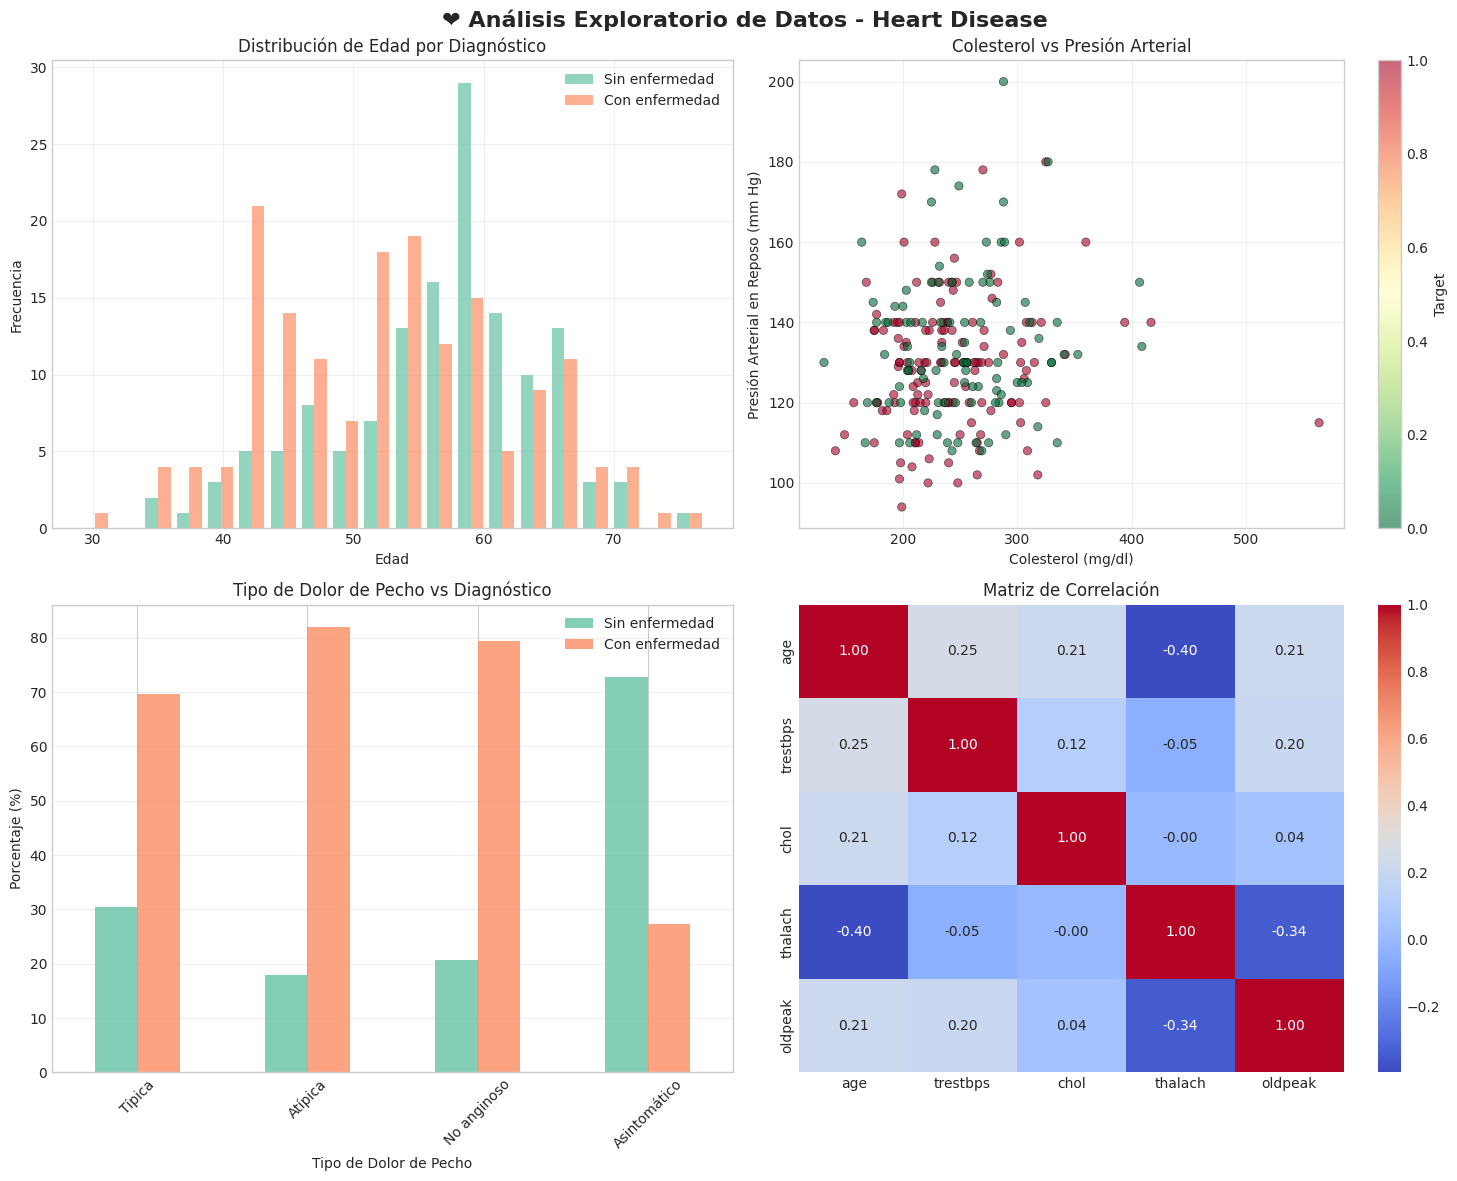

✅ Visualizaciones generadas

💡 TODO: [Completa aquí] ¿Qué patrones observas en los gráficos?


In [0]:
# DONE
# TODO: Crea visualizaciones para explorar patrones del dataset.
# Ideas:
# - Distribución de edad por diagnóstico
# - Colesterol vs presión arterial coloreado por target
# - Tipo de dolor de pecho vs diagnóstico
# - Matriz de correlación

# fig, axes = plt.subplots(2, 2, figsize=(15, 12))
# ...
# plt.show()

# TODO: Escribe qué patrones observas en los gráficos.


# TODO: [Completa aquí] ¿Qué podemos aprender de las visualizaciones?
# dependera de que datos estemos representando y en que graficas los representemos
# Crear figura con múltiples subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('❤️ Análisis Exploratorio de Datos - Heart Disease', fontsize=16, fontweight='bold')

# Gráfico 1: Distribución de edad por target
axes[0, 0].hist([data[data.target==0]['age'], data[data.target==1]['age']], 
                bins=20, label=['Sin enfermedad', 'Con enfermedad'], alpha=0.7)
axes[0, 0].set_xlabel('Edad')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Edad por Diagnóstico')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Colesterol vs Presión Arterial
scatter = axes[0, 1].scatter(data['chol'], data['trestbps'], c=data['target'], 
                             alpha=0.6, cmap='RdYlGn_r', edgecolors='black', linewidth=0.5)
axes[0, 1].set_xlabel('Colesterol (mg/dl)')
axes[0, 1].set_ylabel('Presión Arterial en Reposo (mm Hg)')
axes[0, 1].set_title('Colesterol vs Presión Arterial')
plt.colorbar(scatter, ax=axes[0, 1], label='Target')
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Tipo de dolor de pecho por diagnóstico
cp_target = pd.crosstab(data['cp'], data['target'], normalize='index') * 100
cp_target.plot(kind='bar', ax=axes[1, 0], alpha=0.8)
axes[1, 0].set_xlabel('Tipo de Dolor de Pecho')
axes[1, 0].set_ylabel('Porcentaje (%)')
axes[1, 0].set_title('Tipo de Dolor de Pecho vs Diagnóstico')
axes[1, 0].legend(['Sin enfermedad', 'Con enfermedad'])
axes[1, 0].set_xticklabels(['Típica', 'Atípica', 'No anginoso', 'Asintomático'], rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Gráfico 4: Matriz de correlación (top 10 características)
"""
COMO ME HAY VARIABLES CATEGORICAS Y VARIABLES NUMERICAS LAS VOY A ASEPARAR PARA HACER LA MATRIZ DE CORRELACION

top_features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'ca', 'target']
corr_matrix = data[top_features].corr() # me da error por que sex no es un numero si no strings (Male , Female) person y cramer
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            ax=axes[1, 1], cbar_kws={'label': 'Correlación'})
axes[1, 1].set_title('Matriz de Correlación')

plt.tight_layout()
plt.show()
"""

#NUMERICAS
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
sns.heatmap(data[numeric_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
axes[1, 1].set_title('Matriz de Correlación')

plt.tight_layout()
plt.show()
#plt.title('Correlación de Pearson')
#plt.show()



print("✅ Visualizaciones generadas")
print("\n💡 TODO: [Completa aquí] ¿Qué patrones observas en los gráficos?")
# En la primera grafica se puede ver que hasta +/- los 55 años se diagnostica correctemnte la enfermedad.
#   entre los 55 y los 65 la frecuencias de los diagnosticos errorneos aumenta.
#   despues de los 65 la frecuencia de los acertados es mayor que la de los incorrectos.


**PARA LAS CATEGORICAS:**

In [0]:
#necesito instalar la libreiria para hacer Cramer_V:
%pip install dython
print("instalado correctamnete")

  Attempting uninstall: psutil
    Found existing installation: psutil 7.0.0
    Not uninstalling psutil at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-fd27a17f-678e-4496-a3a7-e85a80a57220
    Can't uninstall 'psutil'. No files were found to uninstall.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [dython]
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


{"ts": "2026-10-01 21:18:20.546", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjY4MjI2MzkzNTM3MDgzMBABIAEyJDAxYTBmOTQzLTE1ZjYtNzA2ZS1hMDExLWJhMmRjNDBjNDFmYTokNDczMTY0NjYtN2UwNS0zYzhmLWJmZTItNjVlMGJhMTk5MTY1SgwI/pL71QYQgPu92AFQAVgBYAFoms+d15HFow2IAQA=.", "context": {}}
{"ts": "2026-10-01 21:18:20.546", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjY4MjI2MzkzNTM3MDgzMBABIAEyJDAxYTBmOTQzLTE1ZjYtNzA2ZS1hMDExLWJhMmRjNDBjNDFmYTokNDczMTY0NjYtN2UwNS0zYzhmLWJmZTItNjVlMGJhMTk5MTY1SgwI/pL71QYQgPu92AFQAVgBYAFoms+d15HFow2IAQA=.", "context": {}}
{"ts": "2026-10-01 21:18:20.546", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjY4MjI2MzkzNTM3MDgzMBABIAEyJDAxYTBmOTQzLTE1ZjYtNzA2ZS1hMDExLWJhMmRjNDBjNDFmYTokNDczMTY0NjYtN2UwNS0zYzhmLWJmZTItNjVlMGJh

instalado correctamnete


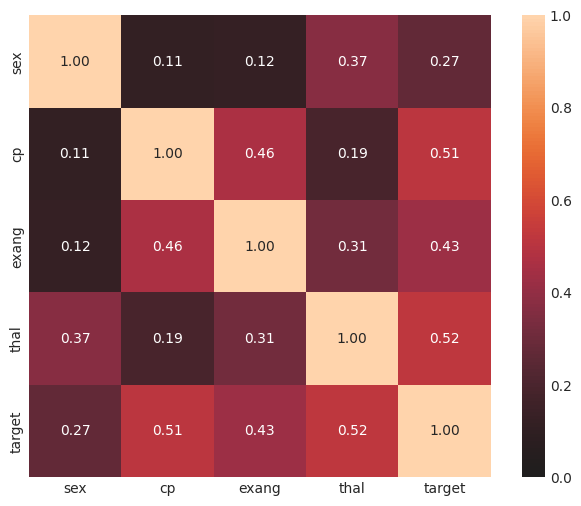

{'corr':              sex        cp     exang      thal    target
 sex     1.000000  0.112353  0.121329  0.371216  0.268144
 cp      0.112353  1.000000  0.461566  0.191089  0.510413
 exang   0.121329  0.461566  1.000000  0.314914  0.426529
 thal    0.371216  0.191089  0.314914  1.000000  0.522014
 target  0.268144  0.510413  0.426529  0.522014  1.000000,
 'ax': <Axes: >}

In [0]:
from dython.nominal import associations
#ESTO ES PARA LAS CATEGORICAS. Hace el Cramers_V
categorical_features = ['sex','cp','exang','thal','target']

associations(
    data[categorical_features],
    nominal_columns=categorical_features,
    figsize=(8, 6)
)

## 🔀 Paso 5: Dividir los Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [0]:
# DONE
# TODO: Divide los datos en train y test.
# Pistas:
# - Usa train_test_split
# - Define test_size
# - Usa random_state para reproducibilidad
# train_set, test_set = train_test_split(...)
# TODO: Comprueba el tamaño de cada conjunto.

# TODO: [Completa aquí] ¿Por qué dividimos en train y test? ¿Qué es test_size y random_state?
""""
Dividimos los datos en entranamiento y test para que podamos entrenar al modelo con unos datos y luego comprobar que resultados realmente da con los datos del test. Estos datos son datos que NO han sido usados para el entrenamiento. si usaramos esos datos en el training y luego en el test el modelo nos daria una acuracy del 100% porque ya sabria que debe responder con esos datos. En cambio de eetsa menra podemos ver si realemnte el modelo funciona o no lo hace, dado que da unos resultados sobre algo nuevo (y que nosotros sabemos que tiene que dar)

Test_size es el tamaño (%) del los datos del test. La diferencia, es el de los de training. Es mas, la proporcion de las clases del training y las del test debe ser igual. Para que se entreene con todas las posibles clases y que el test tambien las tenga. Al ser de igual proporcion, los resultados deben de ser mas fiables y reales

Random state es un valor sobre el que se sacan los valores aleatorios para el reparto de los datos entre train y test en funcion de test size. Es la "semilla". Esta semilla hace que todas las ejecuciones con ese valor den lo mismo. El valor de la semilla se puede cambiar.
"""

train_set, test_set = train_test_split(data, test_size=0.2, random_state=5)

print("=" * 70)
print("🔀 DIVISIÓN DE DATOS")
print("=" * 70)
print(f"📊 Total de muestras: {len(data)}")
print(f"📚 Conjunto de entrenamiento: {len(train_set)} ({len(train_set)/len(data)*100:.1f}%)")
print(f"🧪 Conjunto de prueba: {len(test_set)} ({len(test_set)/len(data)*100:.1f}%)")
print("=" * 70)
print("✅ Datos divididos correctamente")


🔀 DIVISIÓN DE DATOS
📊 Total de muestras: 303
📚 Conjunto de entrenamiento: 242 (79.9%)
🧪 Conjunto de prueba: 61 (20.1%)
✅ Datos divididos correctamente


📊 Generando histogramas de distribuciones...



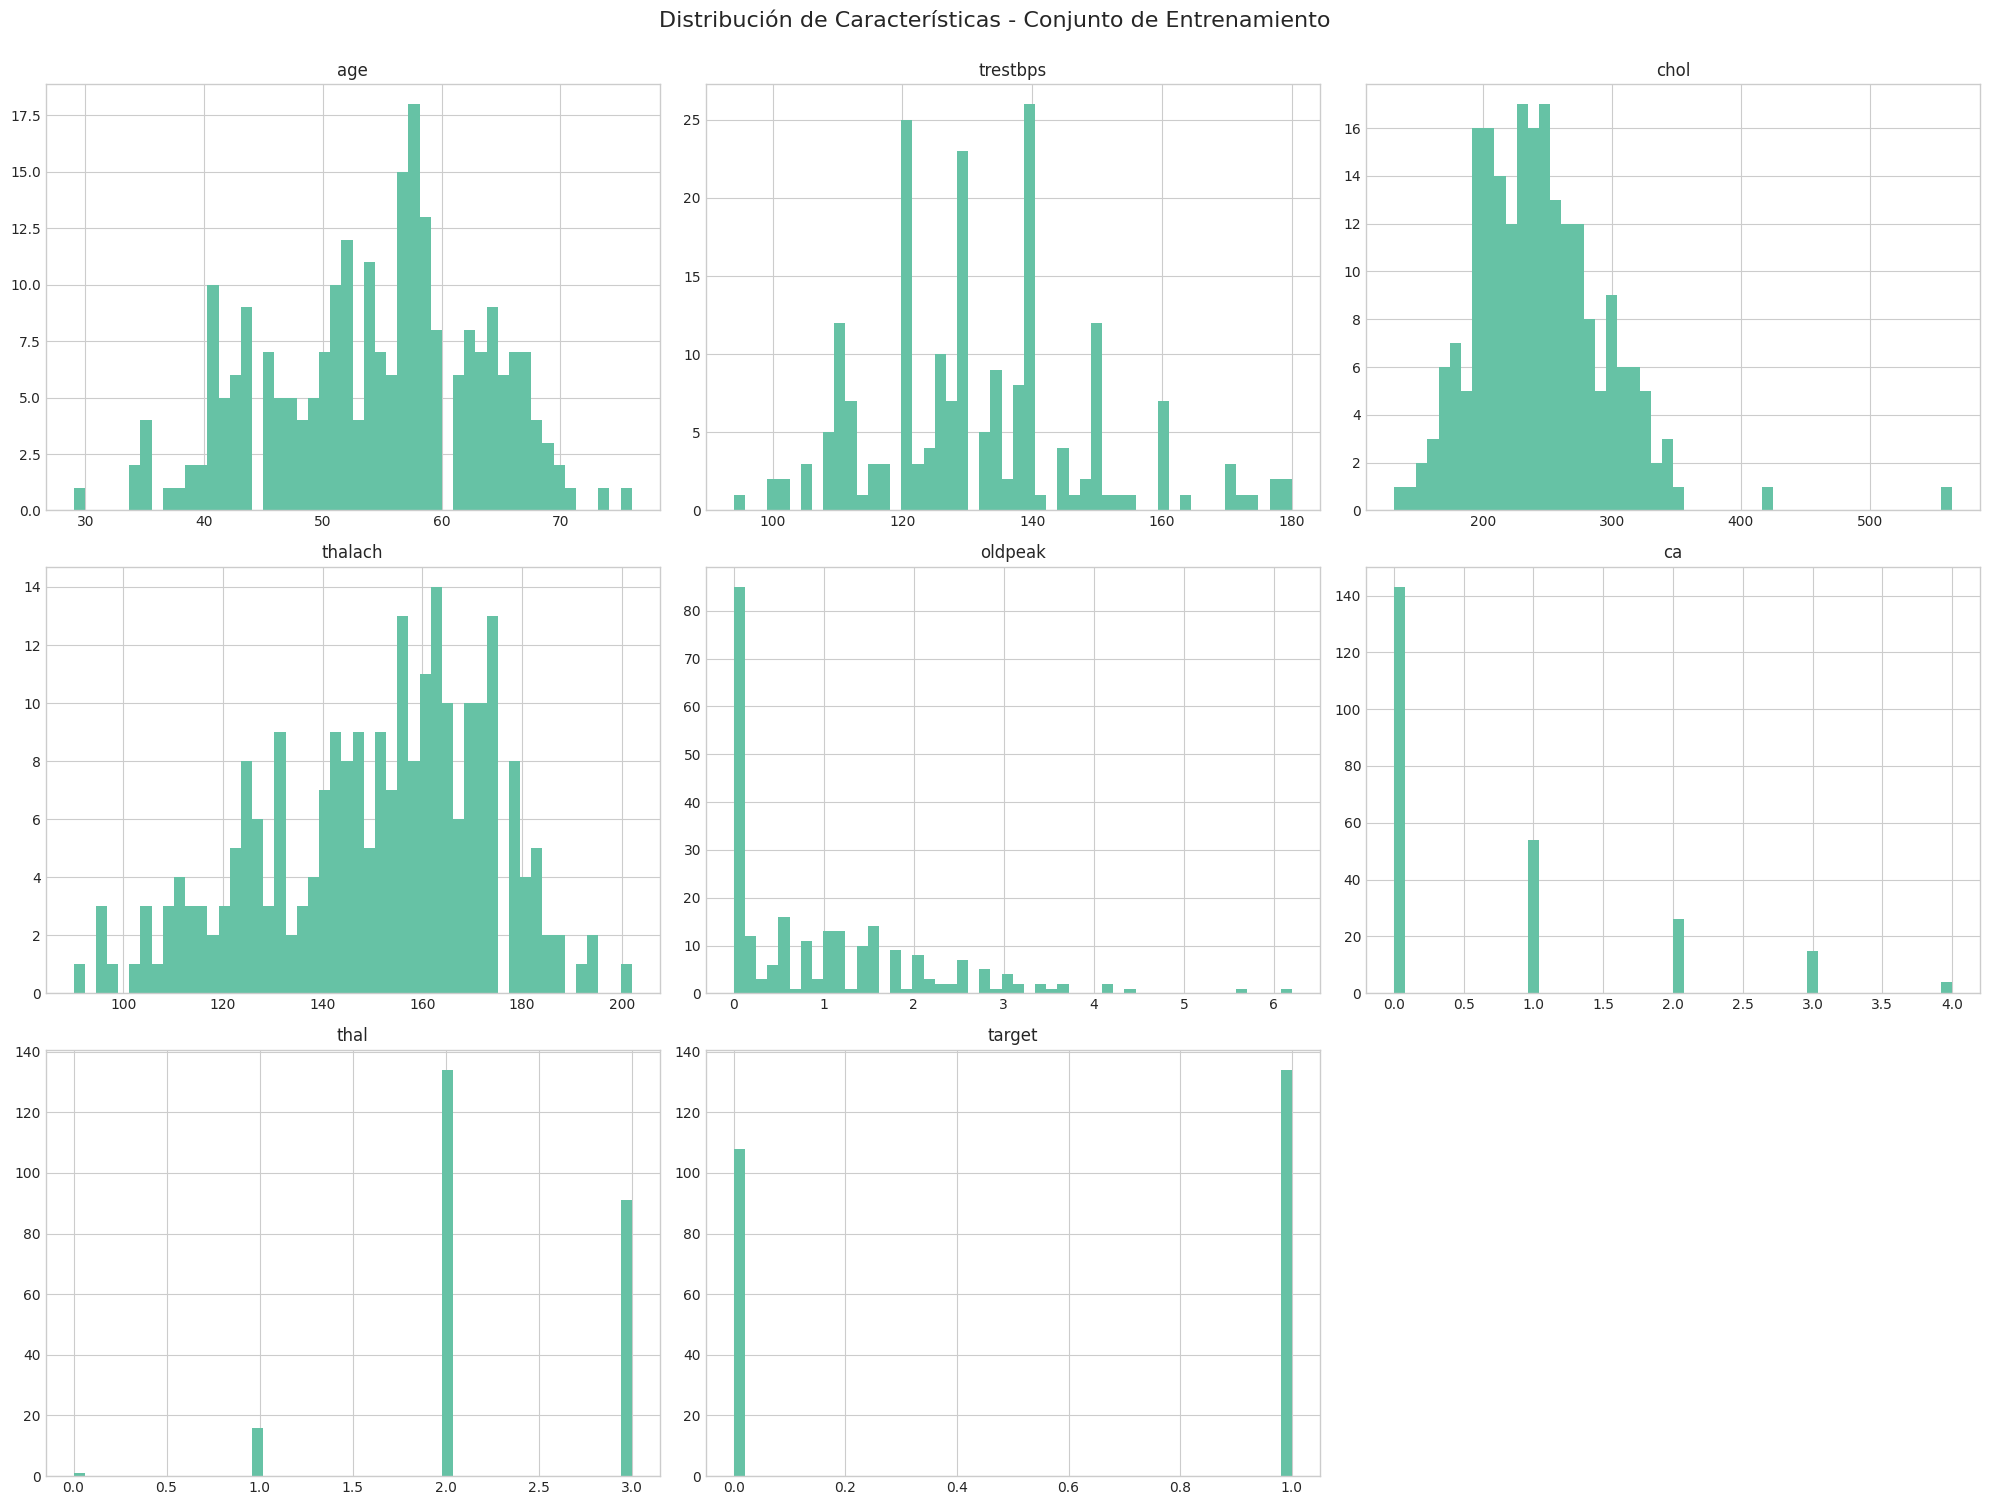

💡 TODO: [Completa aquí] ¿Qué características tienen distribuciones muy diferentes?


In [0]:
# DONE
# TODO: Genera histogramas del conjunto de entrenamiento.
# train_set.hist(bins=50, figsize=(20, 15))
# plt.show()
# TODO: Identifica características con escalas o distribuciones muy diferentes.

# TODO: [Completa aquí] ¿Qué nos muestran los histogramas y por qué son importantes?
# permiten ver la distribucion de los valores
print("📊 Generando histogramas de distribuciones...\n")
train_set.hist(bins=50, figsize=(20, 15))
plt.suptitle('Distribución de Características - Conjunto de Entrenamiento', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

print("💡 TODO: [Completa aquí] ¿Qué características tienen distribuciones muy diferentes?")
# oldpeak y ca tiene distribuciones distintas al resto. Las otras tienen apariencia de distribucion normal.


### 📏 Observación Importante: Escalas Diferentes

DONE

**TODO: [Completa aquí] ¿Por qué es un problema que las características tengan escalas diferentes?**

Revisa columnas como `age`, `trestbps`, `chol`, `thalach` y `oldpeak`.

Porque hay modelos que dan mas importancia a valores mas altos
Las características tienen diferentes escalas:

age: 29-77 años
trestbps: 94-200 mm Hg
chol: 126-564 mg/dl
thalach: 71-202

**TODO: [Completa aquí] ¿Qué transformación aplicarías para que las variables numéricas sean comparables?**
Aplicaremos Standard Scaling (estandarización) para que todas las características tengan:

Media = 0
Desviación estándar = 1

**TODO: [Completa aquí] ¿Por qué esto ayuda a algunos modelos de Machine Learning?**
para evitar que se de mas importancia a unas variables y no a otras.


## 🔧 Paso 6: Construir el Pipeline de Preprocesamiento

Crearemos un pipeline que prepare los datos automáticamente.

In [0]:
# DONE
# TODO: Clasifica las columnas en categóricas y numéricas.
# cat_attr = [...]
# num_attr = [...]
cat_attr = ["sex", "cp", "fbs", "restecg", "exang", "slope"]
num_attr = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca", "thal"]

print("📋 Clasificación de variables:")
print(f"   📊 Numéricas ({len(num_attr)}): {num_attr}")
print(f"   🏷️  Categóricas ({len(cat_attr)}): {cat_attr}")

# TODO: Crea un pipeline para variables numéricas.
# Pistas:
# - SimpleImputer para valores nulos
# - StandardScaler para estandarizar
# num_pipeline = Pipeline([
#     (...),
#     (...),
# ])
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # Rellenar valores nulos
    ("std_scaler", StandardScaler()) # Estandarizar
])

# TODO: Crea un ColumnTransformer que combine numéricas y categóricas.
# Pista: usa OneHotEncoder para variables categóricas.
# full_pipeline = ColumnTransformer([
#     (...),
#     (...),
# ])
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attr),      # Pipeline para numéricas
    ("cat", OneHotEncoder(), cat_attr)    # One-Hot Encoding para categóricas
])

# TODO: Explica por qué usamos One-Hot Encoding para categóricas.
print("\n✅ Pipeline de preprocesamiento creado")
print("\n💡 El pipeline:")
print("   1. Rellena valores nulos con la mediana (numéricas)")
print("   2. Estandariza variables numéricas (media=0, std=1)")
print("   3. Aplica One-Hot Encoding a variables categóricas")
print("\n💡 TODO: [Completa aquí] ¿Por qué One-Hot Encoding para categóricas?\nse usa para variiables categoricas ya que cambia las categorias por valores binarios")


📋 Clasificación de variables:
   📊 Numéricas (7): ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal']
   🏷️  Categóricas (6): ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']

✅ Pipeline de preprocesamiento creado

💡 El pipeline:
   1. Rellena valores nulos con la mediana (numéricas)
   2. Estandariza variables numéricas (media=0, std=1)
   3. Aplica One-Hot Encoding a variables categóricas

💡 TODO: [Completa aquí] ¿Por qué One-Hot Encoding para categóricas?
se usa para variiables categoricas ya que cambia las categorias por valores binarios


## 🎯 Paso 7: Preparar X e y

Separamos características (X) de la variable objetivo (y).

In [0]:
# DONE
# TODO: Separa características (X) y target (y) del conjunto de entrenamiento.
# x_train = ...
# y_train = ...

# TODO: Comprueba las dimensiones resultantes.

x_train = train_set.drop("target", axis=1)  # Características
y_train = train_set.target  # Variable objetivo

print("=" * 70)
print("🎯 SEPARACIÓN DE CARACTERÍSTICAS Y TARGET")
print("=" * 70)
print(f"X_train shape: {x_train.shape} (características)")
print(f"y_train shape: {y_train.shape} (target)")
print("=" * 70)


🎯 SEPARACIÓN DE CARACTERÍSTICAS Y TARGET
X_train shape: (242, 13) (características)
y_train shape: (242,) (target)


In [0]:
# DONE
# TODO: Aplica el pipeline al conjunto de entrenamiento.
x_train_pr = full_pipeline.fit_transform(x_train)

# TODO: Explica la diferencia entre fit_transform y transform.
# fit_transform() hace el fit (entrnamiento) y luego transforma los datos. Esto se puede usar SOLO con los de entrenamiento, ya que con los datos de validacion y test NO se puede netrenar
# es el equivalente a hacer .fit() y luego .transform()
# transform () hace solo la transformacion. Se usa en los datos de validacion y los de test.
# TODO: Comprueba cómo cambia el número de columnas.

print("🔧 Pipeline aplicado al conjunto de entrenamiento")
print(f"   Shape original: {x_train.shape}")
print(f"   Shape procesado: {x_train_pr.shape}")
print(f"\n💡 TODO: [Completa aquí] ¿Por qué cambió el número de columnas?\nPor que al ahcer el oneshot se cambian las variables categoritas por valores binarios, es decri si una variable tiene 3 posibles estados, se cambian por 3 nuevas col de 0 y 1.")

🔧 Pipeline aplicado al conjunto de entrenamiento
   Shape original: (242, 13)
   Shape procesado: (242, 23)

💡 TODO: [Completa aquí] ¿Por qué cambió el número de columnas?
Por que al ahcer el oneshot se cambian las variables categoritas por valores binarios, es decri si una variable tiene 3 posibles estados, se cambian por 3 nuevas col de 0 y 1.


## 🤖 Paso 8: Entrenamiento y Evaluación de Modelos

Entrenaremos dos modelos y compararemos sus resultados usando MLflow.

### 🔵 Modelo 1: SGD Classifier (Baseline)

DONE -> **TODO: [Completa aquí] ¿Qué es SGD (Stochastic Gradient Descent) y cómo funciona?**
Trata de  aprender los parametros minimizando lso errores

Empezaremos con un modelo simple como baseline (línea base) para tener una referencia.

In [0]:
# DONE
# TODO: Activa autolog de MLflow.
mlflow.sklearn.autolog()

# TODO: Inicia un run para el modelo baseline SGD.
with mlflow.start_run(run_name="SGD Classifier - Baseline") as run:

    print("=" * 70)
    print("🚀 ENTRENANDO MODELO BASELINE: SGD CLASSIFIER")
    print("=" * 70)    

    # TODO: Crea SGDClassifier.
    # [Completa aquí] ¿Qué es random_state y por qué lo usamos?
    # Es para que el modelo sea reproducible. Es la semilla
    sgd_clf = SGDClassifier(random_state=42)

    # TODO: Evalúa con cross_val_score.
    # scores = cross_val_score(...)
    # [Completa aquí] ¿Qué es validación cruzada con 3 folds?
    # lo que hace es dividir los datos 3 veces de maneras distintas y calcula el modelo con esas diviisiiones, luego hjace la media de los valores.
    print("\n🔄 Realizando validación cruzada (3-fold)...")
    scores = cross_val_score(sgd_clf, x_train_pr, y_train, cv=3, scoring="accuracy")
    
    print(f"\n📊 Accuracy por fold:")
    for i, score in enumerate(scores, 1):
        print(f"   Fold {i}: {score:.4f} ({score*100:.2f}%)")
    
    print(f"\n📈 Accuracy promedio: {scores.mean():.4f} ± {scores.std():.4f}")

    # TODO: Registra métricas de validación cruzada en MLflow.
    # mlflow.log_metric(...)

    # TODO: Interpreta el resultado obtenido.
    """
    Nuestro modelo da:
    Accuracy por fold:
   Fold 1: 0.7407 (74.07%)
   Fold 2: 0.7531 (75.31%)
   Fold 3: 0.7875 (78.75%)
    Accuracy promedio: 0.7604 ± 0.0198

    El modelo tiene una accuracy de un 76%, ademas es bastanate establa en todos los folds ya que casi no varian. Ademas la variacion standar es menor del 2%
    """
    mlflow.log_metric("cv_accuracy_mean", scores.mean())
    mlflow.log_metric("cv_accuracy_std", scores.std())
    
    print("\n✅ Modelo SGD entrenado con validación cruzada")
    print("=" * 70)


2026/10/01 21:35:06 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 21:35:06 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 21:35:06 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


🚀 ENTRENANDO MODELO BASELINE: SGD CLASSIFIER

🔄 Realizando validación cruzada (3-fold)...


2026/10/01 21:35:06 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-ee418b19-76ae.cloud.databricks.com/ml/experiments/960936713230553/models/m-55944f9bd0284fafb723380ac1de68ef?o=7474656590653338
2026/10/01 21:35:12 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 21:35:13 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 21:35:14 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available


📊 Accuracy por fold:
   Fold 1: 0.7407 (74.07%)
   Fold 2: 0.7531 (75.31%)
   Fold 3: 0.7875 (78.75%)

📈 Accuracy promedio: 0.7604 ± 0.0198

✅ Modelo SGD entrenado con validación cruzada


### 📊 Evaluación del Modelo SGD

In [0]:
# DONE
# TODO: Obtén predicciones con validación cruzada.
# preds = cross_val_predict(...)

print("🔮 Obteniendo predicciones con validación cruzada...")
preds = cross_val_predict(sgd_clf, x_train_pr, y_train, cv=3)
print(f"✅ {len(preds)} predicciones generadas")

# TODO: Explica por qué cross_val_predict es útil para construir métricas y matriz de confusión.
# Es util porque realiza predicciones sobre datos con los que el modelo no fue entrenado. Los resultados que da son con los que luego se pueden hacer analisis. Ademas puedes comparar los resultados con los valores reales y ver si el modelo esta bien encaminado o no.


2026/10/01 21:42:28 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🔮 Obteniendo predicciones con validación cruzada...


2026/10/01 21:42:28 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '995b4cffe8464e2eb6c017b554e5af3e', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/10/01 21:42:29 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 21:42:29 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/01 21:42:29 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-ee418b19-76ae.cloud.databricks.com/ml/experiments/960936713230553/models/m-75a482ba12324b439932e56c380f3fd0?o=7474656

✅ 242 predicciones generadas


📊 Generando matriz de confusión...



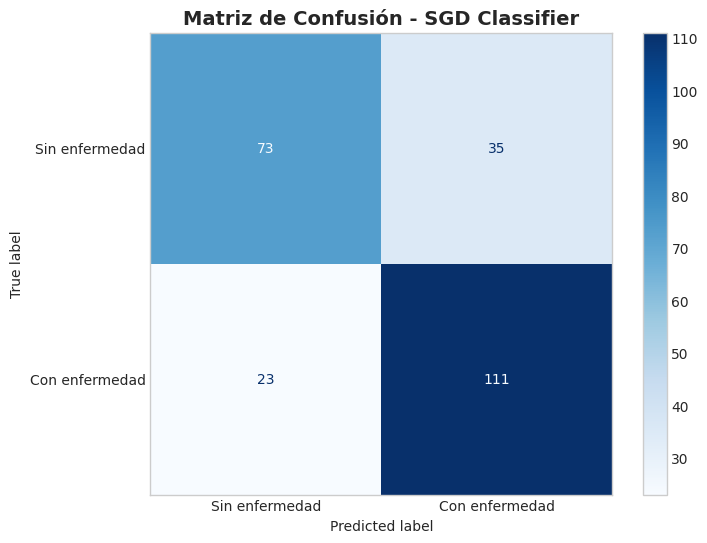


📋 Interpretación de la matriz:
   TN (Verdaderos Negativos): 73 - Correctamente identificados como sanos
   FP (Falsos Positivos): 35 - Sanos clasificados como enfermos
   FN (Falsos Negativos): 23 - Enfermos clasificados como sanos ⚠️
   TP (Verdaderos Positivos): 111 - Correctamente identificados como enfermos

💡 TODO: [Completa aquí] ¿Qué tipo de error es más grave en medicina?


In [0]:
# DONE
# TODO: Calcula y visualiza la matriz de confusión del modelo SGD.
# cm = confusion_matrix(...)
# disp = ConfusionMatrixDisplay(...)
# disp.plot(...)
# plt.show()

# TODO: Interpreta TN, FP, FN y TP.
# TODO: ¿Qué tipo de error es más grave en medicina?
# TODO: [Completa aquí] ¿Qué nos muestra la matriz de confusión?
"""
LA matriz nos muestra la realcion entre los valores reales y los valores predichos, en este caso de nefermos.
TN: true negative -> personas que han salido sanas que son sanas
FP: false positive-> personas sanas que han dado que enstan enfermas
FN: false negative -> personas enfermas que han dado que son sanas
TP: true positive -> personas enfermas que han dado que estan enfermas

En mi opinion en medicina lo peor es un false negative ya que significa que le han dicho a una persona enferma que esta sana. Si es una enfermedad grave puede ser muy peligroso. 
Tambien puede ser malo el false positive ya que ppuedes causarle a una persona mucho malestar psicologico o incluso fisico dependiendo del tratamiento que se le deba hacer.
"""
print("📊 Generando matriz de confusión...\n")

cm = confusion_matrix(y_train, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Sin enfermedad', 'Con enfermedad'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - SGD Classifier', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

print(f"\n📋 Interpretación de la matriz:")
print(f"   TN (Verdaderos Negativos): {cm[0,0]} - Correctamente identificados como sanos")
print(f"   FP (Falsos Positivos): {cm[0,1]} - Sanos clasificados como enfermos")
print(f"   FN (Falsos Negativos): {cm[1,0]} - Enfermos clasificados como sanos ⚠️")
print(f"   TP (Verdaderos Positivos): {cm[1,1]} - Correctamente identificados como enfermos")
print(f"\n💡 TODO: [Completa aquí] ¿Qué tipo de error es más grave en medicina?")



In [0]:
# DONE
# TODO: Calcula métricas del modelo SGD.
# precision = precision_score(...)
# recall = recall_score(...)
# f1 = f1_score(...)
# roc_auc = roc_auc_score(...)

# TODO: Imprime e interpreta las métricas.
# TODO: ¿Qué métrica es más importante en medicina y por qué?

# TODO: [Completa aquí] ¿Qué mide cada una de estas métricas?
print("=" * 70)
print("📊 MÉTRICAS DEL MODELO SGD")
print("=" * 70)

precision = precision_score(y_train, preds) #precision de aciertos
recall = recall_score(y_train, preds) #capacidad de encontrar todos los TP
f1 = f1_score(y_train, preds) #la media armonica de la precision y recall (da mas peso a los valores pequeñso)
roc_auc = roc_auc_score(y_train, preds) #evalua la calidad para separar las clases

print(f"🎯 Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"   → De los que predije como enfermos, el {precision*100:.1f}% realmente lo están")
print(f"\n❤️  Recall: {recall:.4f} ({recall*100:.2f}%)")
print(f"   → Detecté el {recall*100:.1f}% de todos los enfermos reales")
print(f"\n⚖️  F1 Score: {f1:.4f}")
print(f"   → Balance entre precision y recall")
print(f"\n📈 ROC-AUC Score: {roc_auc:.4f}")
print(f"   → Capacidad de discriminación del modelo")
print("=" * 70)

print("\n💡 TODO: [Completa aquí] ¿Qué métrica es más importante en medicina y por qué?\n   recall/sensibilidad, porque queremos minimizar los FN.Un recall bajo implica muchos falsos negativos (FN). Aunque no podemos descuidar un nivel bajo de FP por lo que ya explique anteriormente")




📊 MÉTRICAS DEL MODELO SGD
🎯 Precision: 0.7603 (76.03%)
   → De los que predije como enfermos, el 76.0% realmente lo están

❤️  Recall: 0.8284 (82.84%)
   → Detecté el 82.8% de todos los enfermos reales

⚖️  F1 Score: 0.7929
   → Balance entre precision y recall

📈 ROC-AUC Score: 0.7521
   → Capacidad de discriminación del modelo

💡 TODO: [Completa aquí] ¿Qué métrica es más importante en medicina y por qué?
   recall/sensibilidad, porque queremos minimizar los FN.Un recall bajo implica muchos falsos negativos (FN). Aunque no podemos descuidar un nivel bajo de FP por lo que ya explique anteriormente


### 🌲 Modelo 2: Random Forest Classifier

DONE

**TODO: [Completa aquí] ¿Qué es Random Forest y por qué suele funcionar mejor que modelos simples?**

Es un conjunto de decisionTrees. Cada uno hace sus predicciones de manera independiente y con un conjunto de datos distinto. Luego las "poenen en comun" y se elige la mayoria.
Al ser varios arboles con distintas metricas y conjunto de datos aunque un arbol se equivoque el resto puede acertar, por loque el global sera el correcto.

Ahora probemos un modelo más potente y comparemos resultados.

In [0]:
# DONE
# TODO: Entrena y evalúa un Random Forest en un nuevo run de MLflow.
# with mlflow.start_run(run_name="Random Forest Classifier") as run:
#     rf_clf = RandomForestClassifier(...)
#     rf_scores = cross_val_score(...)
#     rf_preds = cross_val_predict(...)
#     mlflow.log_metric(...)
#
# TODO: Explica qué hiperparámetros podrías ajustar y por qué comparas contra SGD.
# son modelos distintos. EL SGD busca relaciones lineales, en cambio en randomforest puede encontrar otro tipo de realciones.

# Continuar con MLflow (nuevo run para Random Forest)
with mlflow.start_run(run_name="Random Forest Classifier") as run:
    
    print("=" * 70)
    print("🚀 ENTRENANDO MODELO: RANDOM FOREST CLASSIFIER")
    print("=" * 70)
    
    # TODO: [Completa aquí] ¿Qué hiperparámetros podríamos ajustar en Random Forest?
    #tiene muchos entre los que estan: n_estimators (nuemor de arboles), max_depth(profundidad del arbol), min_samples_split(numero observaciones necesarias para dividir un nodo), min_samples_leaf(nuemor de observaciones que debe tener un nodo, a mayor menos especiifco es)
    
    rf_clf = RandomForestClassifier(random_state=42)
    
    # TODO: [Completa aquí] ¿Por qué volvemos a hacer validación cruzada?
    # en primer lugar se hace ya que en el otro tambien lo hicimos, asi se tiene  resultados equivalentes. Por otro lado tambien s ehace para evaluar los modelos y asi estimar su rendimiento y comprobar su variabilidad
    print("\n🔄 Realizando validación cruzada (3-fold)...")
    rf_scores = cross_val_score(rf_clf, x_train_pr, y_train, cv=3, scoring="accuracy")
    
    print(f"\n📊 Accuracy por fold:")
    for i, score in enumerate(rf_scores, 1):
        print(f"   Fold {i}: {score:.4f} ({score*100:.2f}%)")
    
    print(f"\n📈 Accuracy promedio: {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")
    
    # Obtener predicciones
    rf_preds = cross_val_predict(rf_clf, x_train_pr, y_train, cv=3)
    
    # Registrar en MLflow
    mlflow.log_metric("cv_accuracy_mean", rf_scores.mean())
    mlflow.log_metric("cv_accuracy_std", rf_scores.std())
    
    print("\n✅ Modelo Random Forest entrenado")
    print("=" * 70)






2026/10/01 22:27:45 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 22:27:45 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 22:27:45 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


🚀 ENTRENANDO MODELO: RANDOM FOREST CLASSIFIER

🔄 Realizando validación cruzada (3-fold)...


2026/10/01 22:27:45 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-ee418b19-76ae.cloud.databricks.com/ml/experiments/960936713230553/models/m-d90cd882e43045b786a20ffd4fbce526?o=7474656590653338
2026/10/01 22:27:49 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 22:27:51 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 22:27:51 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available


📊 Accuracy por fold:
   Fold 1: 0.8025 (80.25%)
   Fold 2: 0.7778 (77.78%)
   Fold 3: 0.8000 (80.00%)

📈 Accuracy promedio: 0.7934 ± 0.0111


2026/10/01 22:28:04 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-ee418b19-76ae.cloud.databricks.com/ml/experiments/960936713230553/models/m-0cf2ba33f6974505919b1555e7886fc3?o=7474656590653338
2026/10/01 22:28:09 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 22:28:10 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 22:28:10 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available


✅ Modelo Random Forest entrenado


📊 Matriz de Confusión - Random Forest



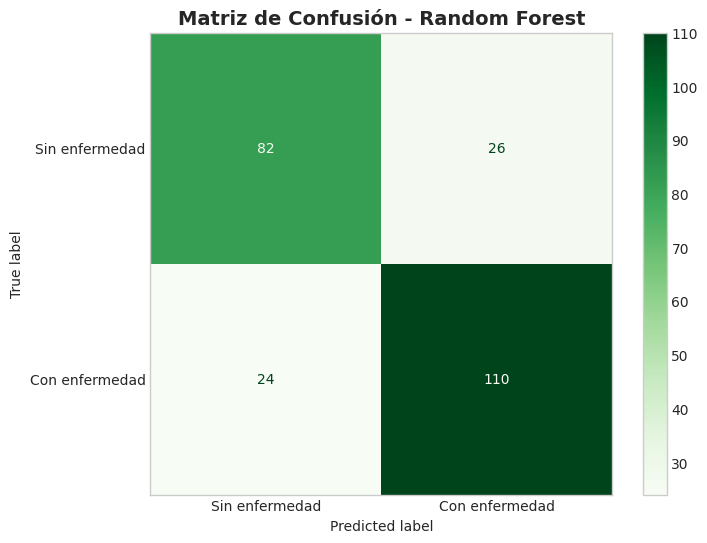


📋 Interpretación:
   TN: 82 | FP: 26
   FN: 24 | TP: 110

💡 TODO: [Completa aquí] ¿Mejoró respecto a SGD? ¿En qué?


In [0]:
# DONE
# TODO: Calcula y visualiza la matriz de confusión de Random Forest.
# cm_rf = confusion_matrix(...)
# disp_rf = ConfusionMatrixDisplay(...)
# disp_rf.plot(...)
# plt.show()
# TODO: Compara los errores con los del modelo SGD.

# TODO: [Completa aquí] ¿Esperamos que la matriz de confusión sea mejor? ¿Por qué?
#Yo pienso que si, ya que dentro de un propio modelo estan actuando varios modelos distintos, de entre los que los arboles "votan".
print("📊 Matriz de Confusión - Random Forest\n")

cm_rf = confusion_matrix(y_train, rf_preds)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=['Sin enfermedad', 'Con enfermedad'])
fig, ax = plt.subplots(figsize=(8, 6))
disp_rf.plot(ax=ax, cmap='Greens')
plt.title('Matriz de Confusión - Random Forest', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

print(f"\n📋 Interpretación:")
print(f"   TN: {cm_rf[0,0]} | FP: {cm_rf[0,1]}")
print(f"   FN: {cm_rf[1,0]} | TP: {cm_rf[1,1]}")
print(f"\n💡 TODO: [Completa aquí] ¿Mejoró respecto a SGD? ¿En qué?")

"""
Ha mejorado en en los TN y FP, ya que han dado mas TN y menos FP. Sin embargo ha empeorado en los FN y TP, ya que FN ha subido uno y TP ha bajado uno. 
Esto nos demuestra que no se puede mejorar por un lado sin perjudicar otro lado. Es decir, mejoras la precision de la respuesta en unos datos pero la bajas en otros. 
Si tenemos en cuante las repsuetas que di anteriormente, para nosotros es importante tener buena deteccion de los TP y FN que han empeorado.
Y aunque hay dos valores que han bajado, relativamente han bajado menos que lo que los otros han suibod. 
Asique para mi este modelo merece la pena, sin embargo hay que tener en cuanta que es loq ue se esta diagnosticando, ya que dependera de si es muy grave o no, el que merezca o no cambiar el SGD por este modelo, debido a que hay un FN mas y un TP mas.

"""



In [0]:
# DONE
# TODO: Calcula métricas de Random Forest.
# rf_precision = precision_score(...)
# rf_recall = recall_score(...)
# rf_f1 = f1_score(...)
# rf_roc_auc = roc_auc_score(...)
# TODO: Crea una tabla comparativa SGD vs Random Forest.
# TODO: Decide qué modelo funciona mejor y justifica tu respuesta.

# TODO: [Completa aquí] ¿Cómo se comparan estas métricas con las de SGD?
#Se comapran mediante la precision, la recall, el f1 y la ROC_AUC
print("=" * 70)
print("📊 MÉTRICAS DEL MODELO RANDOM FOREST")
print("=" * 70)
#las del arbol, ya que ya calculamos antes lsas de SGD:
rf_precision = precision_score(y_train, rf_preds)
rf_recall = recall_score(y_train, rf_preds)
rf_f1 = f1_score(y_train, rf_preds)
rf_roc_auc = roc_auc_score(y_train, rf_preds)

print(f"🎯 Precision: {rf_precision:.4f} ({rf_precision*100:.2f}%)")
print(f"❤️  Recall: {rf_recall:.4f} ({rf_recall*100:.2f}%)")
print(f"⚖️  F1 Score: {rf_f1:.4f}")
print(f"📈 ROC-AUC Score: {rf_roc_auc:.4f}")
print("=" * 70)

# Comparación con SGD
print("\n📊 COMPARACIÓN SGD vs RANDOM FOREST")
print("=" * 70)
comparison = pd.DataFrame({
    'Métrica': ['Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'SGD': [precision, recall, f1, roc_auc],
    'Random Forest': [rf_precision, rf_recall, rf_f1, rf_roc_auc],
    'Diferencia': [
        rf_precision - precision,
        rf_recall - recall,
        rf_f1 - f1,
        rf_roc_auc - roc_auc
    ]
})
print(comparison.to_string(index=False))
print("=" * 70)

print("\n💡 TODO: [Completa aquí] ¿Qué modelo funciona mejor y por qué?")
#En general funaciona mejor el Random forest ya que consigue mejores valores en las metricas estudiadas (precision: reduce los FP, f1: hace la media armonica entre recall y precision, el que sea mejor en este modelo indica que tiene un mejor equilibrio; ROC-AUC:  mejor clasificacion entre sano/enfermo). Esto se debe a que el modelo random forest es un modelo que combina varios arboles de decisiones, por lo que puede mejorar la precision y recall de los datos. Sin embargo, en la recall score (capacidad de detectar a los pacientes que realmente están enfermos) consigue un puntuaje ligeramnte peor, mas bajo que el del SGD.


📊 MÉTRICAS DEL MODELO RANDOM FOREST
🎯 Precision: 0.8088 (80.88%)
❤️  Recall: 0.8209 (82.09%)
⚖️  F1 Score: 0.8148
📈 ROC-AUC Score: 0.7901

📊 COMPARACIÓN SGD vs RANDOM FOREST
  Métrica      SGD  Random Forest  Diferencia
Precision 0.760274       0.808824    0.048550
   Recall 0.828358       0.820896   -0.007463
 F1-Score 0.792857       0.814815    0.021958
  ROC-AUC 0.752142       0.790077    0.037935

💡 TODO: [Completa aquí] ¿Qué modelo funciona mejor y por qué?


## 🎯 Paso 9: Entrenamiento Final y Evaluación en Test

Ahora entrenaremos el modelo con **todo el conjunto de entrenamiento** y evaluaremos en el conjunto de prueba (que nunca ha visto).

In [0]:
# DONE
# TODO: Entrena el modelo final usando todo el conjunto de entrenamiento procesado.
# forest_clf = RandomForestClassifier(...)
# forest_clf.fit(...)
# TODO: Explica por qué ahora entrenamos con todos los datos de train.
# TODO: [Completa aquí] ¿Por qué ahora entrenamos con todos los datos de train?
#se entrena con todos los datos del train (train+validation) ya que ahora que tenemos el modelo que hemos vistos tiene mejor rendimiento ya no necesitamos usar validation, por que ya tenemos todas las metricas que hemos visto que son validas.

print("🎯 Entrenamiento final con todo el conjunto de entrenamiento\n")

forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(x_train_pr, y_train)

print("✅ Modelo Random Forest entrenado con", len(x_train_pr), "muestras")
print("📊 El modelo ahora tiene más datos para aprender patrones")


2026/10/01 23:24:37 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🎯 Entrenamiento final con todo el conjunto de entrenamiento



2026/10/01 23:24:37 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'b62eeec5791143b8976ab112ad841a1d', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/10/01 23:24:37 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/01 23:24:37 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/01 23:24:37 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-ee418b19-76ae.cloud.databricks.com/ml/experiments/960936713230553/models/m-917b1585f6ca42ed84e124b489d34583?o=7474656

✅ Modelo Random Forest entrenado con 242 muestras
📊 El modelo ahora tiene más datos para aprender patrones


In [0]:
# DONE
# TODO: Separa características y target del conjunto de prueba.
# x_test = ...
# y_test = ...
# TODO: Comprueba dimensiones.
"""
 X_test: (61, 13) -> 61 pacientes 13 caracteristicas
   y_test: (61,) -> 61 àcientes
"""
# TODO: [Completa aquí] ¿Por qué preparamos los datos de test de la misma manera?
#Lo ahcemos para que los datos del test tengan el mismo formato y transformaciones que los de entranmiento
x_test = test_set.drop("target", axis=1)
y_test = test_set.target

print("🧪 Conjunto de prueba preparado:")
print(f"   X_test: {x_test.shape}")
print(f"   y_test: {y_test.shape}")


🧪 Conjunto de prueba preparado:
   X_test: (61, 13)
   y_test: (61,)


In [0]:
# DONE
# TODO: Transforma el conjunto de prueba y genera predicciones.
# x_test_pr = full_pipeline.transform(x_test)
# final_preds = forest_clf.predict(x_test_pr)
# TODO: Explica por qué usamos transform() y no fit_transform() en test.

# TODO: [Completa aquí] ¿Por qué usamos transform() y no fit_transform()?

#Usamos transform() y no fit_transform() por que no queremos volver a entrenar el modelo. Si lo hicieramos seria un data leakage ya qeu lo estarimos entrenamdo con los datos del test. fit_transform() hace el fit y luego transforma 
# Con transform solo transforma los ddatos y no los entrena. Por ello es el que usamos para los datos del test

x_test_pr = full_pipeline.transform(x_test)
final_preds = forest_clf.predict(x_test_pr)

print("🔮 Predicciones en conjunto de prueba generadas")
print(f"   Datos procesados: {x_test_pr.shape}")
print(f"   Predicciones: {len(final_preds)}")
print("\n💡 TODO: [Completa aquí] ¿Por qué NO debemos usar fit_transform en test?")


2026/10/01 23:33:13 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🔮 Predicciones en conjunto de prueba generadas
   Datos procesados: (61, 23)
   Predicciones: 61

💡 TODO: [Completa aquí] ¿Por qué NO debemos usar fit_transform en test?


🎉 RESULTADOS FINALES EN CONJUNTO DE PRUEBA
🎯 Accuracy: 0.9016 (90.16%)
🎯 Precision: 0.8788 (87.88%)
❤️  Recall: 0.9355 (93.55%)
⚖️  F1 Score: 0.9062
📈 ROC-AUC: 0.9011

📊 Matriz de Confusión Final:



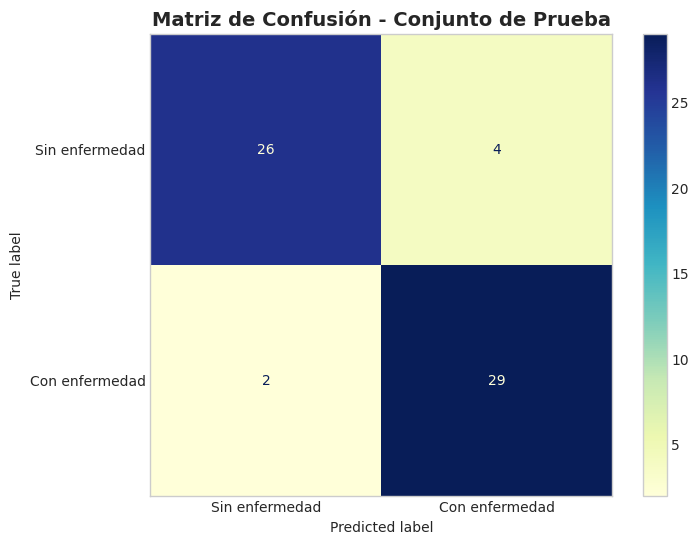


📋 REPORTE DE CLASIFICACIÓN DETALLADO:
                precision    recall  f1-score   support

Sin enfermedad     0.9286    0.8667    0.8966        30
Con enfermedad     0.8788    0.9355    0.9062        31

      accuracy                         0.9016        61
     macro avg     0.9037    0.9011    0.9014        61
  weighted avg     0.9033    0.9016    0.9015        61


💡 TODO: [Completa aquí] ¿El modelo generaliza bien? ¿Cómo lo sabes?


In [0]:
# DONE
# TODO: Evalúa resultados finales en el conjunto de prueba.
# final_precision = precision_score(...)
# final_recall = recall_score(...)
# final_f1 = f1_score(...)
# final_roc_auc = roc_auc_score(...)
# final_accuracy = accuracy_score(...)

# TODO: Visualiza la matriz de confusión final.
# TODO: Genera classification_report.
# TODO: Interpreta si el modelo generaliza bien.

# TODO: [Completa aquí] ¿Qué significan estos resultados en el conjunto de prueba?
print("=" * 70)
print("🎉 RESULTADOS FINALES EN CONJUNTO DE PRUEBA")
print("=" * 70)

final_precision = precision_score(y_test, final_preds)
final_recall = recall_score(y_test, final_preds)
final_f1 = f1_score(y_test, final_preds)
final_roc_auc = roc_auc_score(y_test, final_preds)
final_accuracy = accuracy_score(y_test, final_preds)

print(f"🎯 Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")
print(f"🎯 Precision: {final_precision:.4f} ({final_precision*100:.2f}%)")
print(f"❤️  Recall: {final_recall:.4f} ({final_recall*100:.2f}%)")
print(f"⚖️  F1 Score: {final_f1:.4f}")
print(f"📈 ROC-AUC: {final_roc_auc:.4f}")
print("=" * 70)

# Matriz de confusión final
print("\n📊 Matriz de Confusión Final:\n")
cm_final = confusion_matrix(y_test, final_preds)
disp_final = ConfusionMatrixDisplay(cm_final, display_labels=['Sin enfermedad', 'Con enfermedad'])
fig, ax = plt.subplots(figsize=(8, 6))
disp_final.plot(ax=ax, cmap='YlGnBu')
plt.title('Matriz de Confusión - Conjunto de Prueba', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

# Reporte de clasificación completo
print("\n📋 REPORTE DE CLASIFICACIÓN DETALLADO:")
print("=" * 70)
print(classification_report(y_test, final_preds, 
                          target_names=['Sin enfermedad', 'Con enfermedad'],
                          digits=4))
print("=" * 70)

print("\n💡 TODO: [Completa aquí] ¿El modelo generaliza bien? ¿Cómo lo sabes?")

"""
El modelo presenta buen rendimiento.
Los FP son 4 y los FN son 2 (es cierto que es uno de los valores que mas nos importan pero es un valor bajo). Los TN son 26 y los TP son 29. Es decir que las predicciones mayormente acertadas tanto en los positivos como en los negativos.
La accuracy (precision de aciertos) es del 90%, la precision (de TP) de casi un 88% (87.88%), el recall de un 93.55% (los que dijo que eran P y realmente eran P), la f1 score de un 90.62% y la ROCAUC (capacidad del modelo de clasificar correctamente) de un 90.11%. Todos los valores superan o rondan el 90%

"""




## 🎉 Reflexión Final del Proyecto

Completa esta sección cuando termines el notebook.

### ✅ Comprueba que has trabajado

1. [ ] Exploración de datos médicos reales
2. [ ] Pipeline de preprocesamiento
3. [ ] Entrenamiento y comparación de modelos
4. [ ] Evaluación con métricas de clasificación
5. [ ] Validación cruzada
6. [ ] Registro de experimentos en MLflow
7. [ ] Interpretación de resultados con matrices de confusión

### 📊 Conclusiones Clave

DONE

**TODO: Basándote en tus resultados, escribe tus conclusiones:**

1. **¿Qué modelo funcionó mejor?**
   - El modelo que mejor funciono es el del RandomForest

2. **¿Por qué crees que funcionó mejor?**
   - En general funaciona mejor el Random forest ya que consigue mejores valores en las metricas estudiadas (precision: reduce los FP, f1: hace la media armonica entre recall y precision, el que sea mejor en este modelo indica que tiene un mejor equilibrio; ROC-AUC:  mejor clasificacion entre sano/enfermo). Esto se debe a que el modelo random forest es un modelo que combina varios arboles de decisiones, por lo que puede mejorar la precision y recall de los datos. Sin embargo, en la recall score (capacidad de detectar a los pacientes que realmente están enfermos) consigue un puntuaje ligeramnte peor, mas bajo que el del SGD.

3. **¿El modelo es suficientemente bueno para uso médico?**
   - en mi opinion si, ya que, la accuracy (precision de aciertos) es del 90%, la precision (de TP) de casi un 88% (87.88%), el recall de un 93.55% (los que dijo que eran P y realmente eran P), la f1 score de un 90.62% y la ROCAUC (capacidad del modelo de clasificar correctamente) de un 90.11%. Todos los valores superan o rondan el 90%. Sin embargo es cierto que aun sucenden FN y tambien algun FP, por lo que para las enfermedades mas graves o peligrosas o en las que hubiera mas consecuencias por haberlas diagnosticado mal, haria mas checkeos medicos y no me fieria solo del modelo.

4. **¿Qué métrica es más importante en este caso?**
   -  La recall score o capacidad de detectar a los pacientes que realmente están enfermos

5. **¿Qué mejorarías del modelo?**
   - Usaria distintos hiperparametros para tratar de encontrar un mejor recall (para reducir el % FN), sin perjudicar las otras metricas.

---

### 💡 Reflexiones Importantes

#### ⚕️ Sobre Medicina e IA

DONE

**TODO: Reflexiona sobre:**

1. **Falsos Negativos vs Falsos Positivos**
   - En medicina, ¿cuál es más grave y por qué?
   - Dependera mucho de la enfermedad que se este diagnosticamdo.
   Si es una enfermedad muy dañina entonces es el FN ya qeu una persona enferma se le esta diciendo que no lo esta. Eso hace que se retrase el moento de diagnostico y por lo tanto dificulte su yratamiento. Sin embargo un FP tambien resulta malo ya que le estas causando un estres fisico y emocional grande si la enfermedad es de dificil curacion. Ademas en caso de que sea curable pero el tratamiento sea dificil o duro tambien le afectas la salud fisica y mental. 

2. **Responsabilidad Ética**
   - ¿Puede un modelo de IA tomar decisiones médicas solo?
   - No. Un modelo IA puede ayudar a diagnosticarlas, a ayudar al medico a tomar decisiones o incluso a ver cosas que se tardaria en ver (como el diagnostico por imagen de tumores). Sin embargo SIEMPRE debe haber un medico que corrobore el diagnostico d ela IA y que sea ÉL el que trate y diagnostique al paciente. LaIA se peude equivocar.

3. **Interpretabilidad**
   - ¿Por qué es importante que los médicos entiendan cómo decide el modelo?
   - Por que hay muchas cosas que suceden por detras en los modelos. Cuantas menos "cajas negras" haya mejor. Es importante poder saber que esta haciendo el modelo parapoder reproducirlo. Los medicos necesitan saber que esta haciendo la IA para poder confiar en ella en los diagnosticos (siempr supervisada). si ello sno entienden que hace la IA, los medicos decidirian no usarla, dificultando el diagnostico o retrasandolo, ademas de no agilizar los procesos.

---

### 🚀 Desafíos Adicionales

1. **Optimización de Hiperparámetros** con `GridSearchCV`.
2. **Prueba Otros Modelos** como Gradient Boosting, SVM o Logistic Regression.
3. **Feature Engineering** para crear o seleccionar características.
4. **Análisis de Errores** para entender pacientes mal clasificados.
5. **Curva ROC** para comparar thresholds y AUC.


In [0]:
# 🎨 DESAFÍOS OPCIONALES
# Usa este espacio para completar los desafíos del proyecto.

# ========================================
# TODO: DESAFÍO 1 - Grid Search
# ========================================
# from sklearn.model_selection import GridSearchCV
# param_grid = {...}
# grid_search = GridSearchCV(...)
# grid_search.fit(...)

# ========================================
# TODO: DESAFÍO 2 - Curva ROC
# ========================================
# from sklearn.metrics import roc_curve, auc
# y_proba = ...
# fpr, tpr, thresholds = roc_curve(...)
# TODO: visualiza la curva ROC.

# ========================================
# TODO: DESAFÍO 3 - Importancia de características
# ========================================
# feature_names = ...
# feature_importance = ...
# TODO: identifica e interpreta las características más importantes.

# ========================================
# TODO: DESAFÍO 4 - Comparar más modelos
# ========================================
# modelos = {...}
# resultados = []
# for nombre, modelo in modelos.items():
#     # Entrena, evalúa y registra cada modelo en MLflow
#     pass
